In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from params import (
    CAR_PASS_KM_PER_VEH_DISCOUNTED,
    BUS_PASS_KM_PER_VEH_DISCOUNTED,
    TRUCK_TON_KM_PER_VEH_DISCOUNTED,
)

from utils import (
    subsidy_to_constant_usd_by_year,
    average_over_years,
    pick_peak_value,
    df_scale,
    records_to_gcam_xml,
    series_convert_base,
)

In [2]:
dfDef = pd.read_csv("../resources/gdpdef.csv")
dfDef.head()
dfDef['Year'] = dfDef['date'].str.split('-').str[0].astype(int)
arrDef = dfDef.set_index('Year')['gdpdef']
arrDef

Year
1947     11.425
1948     12.065
1949     12.046
1950     12.189
1951     13.059
         ...   
2021    110.157
2022    118.012
2023    122.382
2024    125.422
2025    128.248
Name: gdpdef, Length: 79, dtype: float64

In [3]:
arrDef[1990]

59.305

In [4]:
35359 * arrDef[1990] / arrDef[2018]

20500.60119466604

In [5]:
arrDef[1990] / arrDef[2025]

0.4624243652922463

In [6]:
36689.3984375 * arrDef[1990] / arrDef[2017]

21759.735730145883

In [7]:
21759 * 51684

1124592156

In [8]:
2912586 / 51325.329 * arrDef[1990] / arrDef[2023]

27.49924559424792

# Source

* Data Source:
    * [KECO](https://ev.or.kr/nportal/buySupprt/initSubsidyPaymentCheckAction.do)
    * Repository for ZEV purchase subsidy data: `../resources/ZEV_purchase_subsidy/`

* Implemented Input Files
    * `/input/policy/korea-2035/transportation/ZEV_subsidy_cp.xml`
    * `/input/policy/korea-2035/transportation/ZEV_subsidy_ep.xml`

# ZEV purchasing subsidy

ZEV subsidy data for 2021–2024 are scraped from [KECO](https://ev.or.kr/nportal/buySupprt/initSubsidyPaymentCheckAction.do). Subsidies vary by vehicle type and year, and we use the average subsidy value for each type. In the Current Policies scenario, purchase subsidies are assumed to sunset after 2025. In the Enhanced Ambition scenario, subsidies are assumed to continue at their peak levels through 2035. We convert the subsidy per vehicle into a subsidy per unit of vehicle performance using the conversion factor in the basic_assumption.ipynb file. Detailed implementation steps are provided below.

### Load Data

In [9]:
lstDf = []
for year in range(2021, 2025):
    df = pd.read_csv(f"../resources/ZEV_purchase_subsidy/{year}_pass_LDV_4W_EV.csv")
    lstDf.append(df)
dfBevPassLdv4w = pd.concat(lstDf)

In [10]:
lstDf = []
for year in range(2021, 2025):
    df = pd.read_csv(f"../resources/ZEV_purchase_subsidy/{year}_pass_Bus.csv")
    lstDf.append(df)
dfBevBus = pd.concat(lstDf)

In [11]:
lstDf = []
for year in range(2021, 2025):
    df = pd.read_csv(f"../resources/ZEV_purchase_subsidy/{year}_freight_road.csv")
    lstDf.append(df)
dfBevFreight = pd.concat(lstDf)

In [12]:
dfBevFreight['보조금 (만원)'] = dfBevFreight['보조금 (만원)'].replace('모델별 지방비 자료가 없습니다.', np.nan, regex=True).astype(float)

In [13]:
lstDf = []
for year in range(2021, 2025):
    df = pd.read_csv(f"../resources/ZEV_purchase_subsidy/{year}_FCEV.csv")
    lstDf.append(df)
dfFcev = pd.concat(lstDf)

In [14]:
dfFcevLDV4W = dfFcev[dfFcev['차종'] == '일반승용(수소)'].copy()
dfFcevBus = dfFcev[dfFcev['차종'] == '승합(수소 대형)'].copy()
dfFcevFreight = dfFcev[dfFcev['차종'] == '화물(수소 대형)'].copy()

In [15]:
YEAR_COL = "연도"
VAL_COL  = "보조금 (만원)"

BASE_INPUT = 1990
BASE_PLOT  = 2020
DISCOUNT_R = 0.045

VEH_SCALE  = 1e3   
PERF_SCALE = 1e3  

In [16]:
dfDef = pd.read_csv("../resources/gdpdef.csv")
dfDef.head()
dfDef['Year'] = dfDef['date'].str.split('-').str[0].astype(int)
arrDef = dfDef.set_index('Year')['gdpdef']

dfExc = pd.read_csv("../resources/DEXKOUS.csv")
dfExc['date'] = pd.to_datetime(dfExc['observation_date'])
dfExcAnnual = dfExc.groupby(dfExc['date'].dt.year)['DEXKOUS'].mean()

In [17]:
# -----------------------------
# 2) Per-year subsidy series (constant USD(base_input) per vehicle)
# -----------------------------
s_bev_car   = subsidy_to_constant_usd_by_year(dfBevPassLdv4w, dfExcAnnual=dfExcAnnual, arrDef=arrDef,
                                              base_year=BASE_INPUT, year_col=YEAR_COL, val_col=VAL_COL)
s_bev_bus   = subsidy_to_constant_usd_by_year(dfBevBus,       dfExcAnnual=dfExcAnnual, arrDef=arrDef,
                                              base_year=BASE_INPUT, year_col=YEAR_COL, val_col=VAL_COL)
s_bev_truck = subsidy_to_constant_usd_by_year(dfBevFreight,   dfExcAnnual=dfExcAnnual, arrDef=arrDef,
                                              base_year=BASE_INPUT, year_col=YEAR_COL, val_col=VAL_COL)

s_fcev_car   = subsidy_to_constant_usd_by_year(dfFcevLDV4W,    dfExcAnnual=dfExcAnnual, arrDef=arrDef,
                                               base_year=BASE_INPUT, year_col=YEAR_COL, val_col=VAL_COL)
s_fcev_bus   = subsidy_to_constant_usd_by_year(dfFcevBus,      dfExcAnnual=dfExcAnnual, arrDef=arrDef,
                                               base_year=BASE_INPUT, year_col=YEAR_COL, val_col=VAL_COL)
s_fcev_truck = subsidy_to_constant_usd_by_year(dfFcevFreight,  dfExcAnnual=dfExcAnnual, arrDef=arrDef,
                                               base_year=BASE_INPUT, year_col=YEAR_COL, val_col=VAL_COL)

In [18]:
# -----------------------------
# 3) Current Policies
# -----------------------------
cp_bev_car   = average_over_years(s_bev_car,   2021, 2024)
cp_bev_bus   = average_over_years(s_bev_bus,   2021, 2024)
cp_bev_truck = average_over_years(s_bev_truck, 2021, 2024)

cp_fcev_car   = average_over_years(s_fcev_car,   2021, 2024)
cp_fcev_bus   = average_over_years(s_fcev_bus,   2021, 2024)
cp_fcev_truck = average_over_years(s_fcev_truck, 2022, 2024)  # 네 기존 가정 유지

df_cp_bev_veh = pd.DataFrame({"subsidy_per_vehicle": [cp_bev_car, cp_bev_bus, cp_bev_truck]},
                             index=["Car", "Bus", "Medium truck"])
df_cp_fcev_veh = pd.DataFrame({"subsidy_per_vehicle": [cp_fcev_car, cp_fcev_bus, cp_fcev_truck]},
                              index=["Car", "Bus", "Medium truck"])

df_cp_bev_perf = pd.DataFrame({"subsidy_per_perf": [
    cp_bev_car / CAR_PASS_KM_PER_VEH_DISCOUNTED,
    cp_bev_bus / BUS_PASS_KM_PER_VEH_DISCOUNTED,
    cp_bev_truck / TRUCK_TON_KM_PER_VEH_DISCOUNTED,
]}, index=["Car", "Bus", "Medium truck"])

df_cp_fcev_perf = pd.DataFrame({"subsidy_per_perf": [
    cp_fcev_car / CAR_PASS_KM_PER_VEH_DISCOUNTED,
    cp_fcev_bus / BUS_PASS_KM_PER_VEH_DISCOUNTED,
    cp_fcev_truck / TRUCK_TON_KM_PER_VEH_DISCOUNTED,
]}, index=["Car", "Bus", "Medium truck"])


In [19]:
# -----------------------------
# 4) High Ambition
# -----------------------------
y_bev_car,   ha_bev_car   = pick_peak_value(s_bev_car)
y_bev_bus,   ha_bev_bus   = pick_peak_value(s_bev_bus)
y_bev_truck, ha_bev_truck = pick_peak_value(s_bev_truck)

y_fcev_car,   ha_fcev_car   = pick_peak_value(s_fcev_car)
y_fcev_bus,   ha_fcev_bus   = pick_peak_value(s_fcev_bus)
y_fcev_truck, ha_fcev_truck = pick_peak_value(s_fcev_truck)

max_years_used = {
    "BEV":  {"Car": y_bev_car,  "Bus": y_bev_bus,  "Truck": y_bev_truck},
    "FCEV": {"Car": y_fcev_car, "Bus": y_fcev_bus, "Truck": y_fcev_truck},
}
print("High Ambition peak-year used:", max_years_used)

df_ha_bev_veh = pd.DataFrame({"subsidy_per_vehicle": [ha_bev_car, ha_bev_bus, ha_bev_truck]},
                             index=["Car", "Bus", "Medium truck"])
df_ha_fcev_veh = pd.DataFrame({"subsidy_per_vehicle": [ha_fcev_car, ha_fcev_bus, ha_fcev_truck]},
                              index=["Car", "Bus", "Medium truck"])

df_ha_bev_perf = pd.DataFrame({"subsidy_per_perf": [
    ha_bev_car / CAR_PASS_KM_PER_VEH_DISCOUNTED,
    ha_bev_bus / BUS_PASS_KM_PER_VEH_DISCOUNTED,
    ha_bev_truck / TRUCK_TON_KM_PER_VEH_DISCOUNTED,
]}, index=["Car", "Bus", "Medium truck"])

df_ha_fcev_perf = pd.DataFrame({"subsidy_per_perf": [
    ha_fcev_car / CAR_PASS_KM_PER_VEH_DISCOUNTED,
    ha_fcev_bus / BUS_PASS_KM_PER_VEH_DISCOUNTED,
    ha_fcev_truck / TRUCK_TON_KM_PER_VEH_DISCOUNTED,
]}, index=["Car", "Bus", "Medium truck"])

High Ambition peak-year used: {'BEV': {'Car': 2021, 'Bus': 2021, 'Truck': 2021}, 'FCEV': {'Car': 2021, 'Bus': 2023, 'Truck': 2024}}


In [20]:
# -----------------------------
# 5) Plot versions: convert base_input -> base_plot, then scale
# -----------------------------
# (a) per-vehicle plots: thousand USD/veh
cp_bev_veh_plot  = df_scale(df_cp_bev_veh.assign(subsidy_per_vehicle=series_convert_base(
                        df_cp_bev_veh["subsidy_per_vehicle"], arrDef=arrDef, from_base=BASE_INPUT, to_base=BASE_PLOT)),
                        "subsidy_per_vehicle", VEH_SCALE, "/")
cp_fcev_veh_plot = df_scale(df_cp_fcev_veh.assign(subsidy_per_vehicle=series_convert_base(
                        df_cp_fcev_veh["subsidy_per_vehicle"], arrDef=arrDef, from_base=BASE_INPUT, to_base=BASE_PLOT)),
                        "subsidy_per_vehicle", VEH_SCALE, "/")
ha_bev_veh_plot  = df_scale(df_ha_bev_veh.assign(subsidy_per_vehicle=series_convert_base(
                        df_ha_bev_veh["subsidy_per_vehicle"], arrDef=arrDef, from_base=BASE_INPUT, to_base=BASE_PLOT)),
                        "subsidy_per_vehicle", VEH_SCALE, "/")
ha_fcev_veh_plot = df_scale(df_ha_fcev_veh.assign(subsidy_per_vehicle=series_convert_base(
                        df_ha_fcev_veh["subsidy_per_vehicle"], arrDef=arrDef, from_base=BASE_INPUT, to_base=BASE_PLOT)),
                        "subsidy_per_vehicle", VEH_SCALE, "/")

# (b) per-performance plots: USD per million (pass-km / ton-km)
cp_bev_perf_plot  = df_scale(df_cp_bev_perf.assign(subsidy_per_perf=series_convert_base(
                        df_cp_bev_perf["subsidy_per_perf"], arrDef=arrDef, from_base=BASE_INPUT, to_base=BASE_PLOT)),
                        "subsidy_per_perf", PERF_SCALE, "*")
cp_fcev_perf_plot = df_scale(df_cp_fcev_perf.assign(subsidy_per_perf=series_convert_base(
                        df_cp_fcev_perf["subsidy_per_perf"], arrDef=arrDef, from_base=BASE_INPUT, to_base=BASE_PLOT)),
                        "subsidy_per_perf", PERF_SCALE, "*")
ha_bev_perf_plot  = df_scale(df_ha_bev_perf.assign(subsidy_per_perf=series_convert_base(
                        df_ha_bev_perf["subsidy_per_perf"], arrDef=arrDef, from_base=BASE_INPUT, to_base=BASE_PLOT)),
                        "subsidy_per_perf", PERF_SCALE, "*")
ha_fcev_perf_plot = df_scale(df_ha_fcev_perf.assign(subsidy_per_perf=series_convert_base(
                        df_ha_fcev_perf["subsidy_per_perf"], arrDef=arrDef, from_base=BASE_INPUT, to_base=BASE_PLOT)),
                        "subsidy_per_perf", PERF_SCALE, "*")

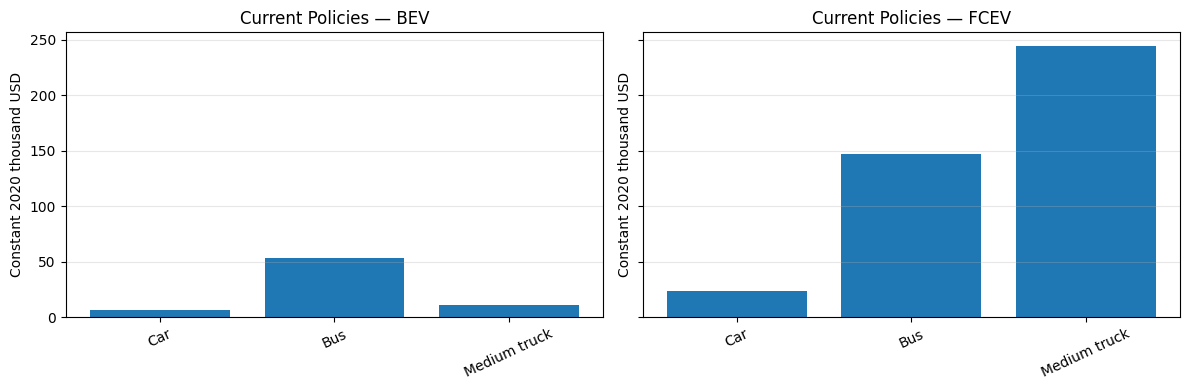

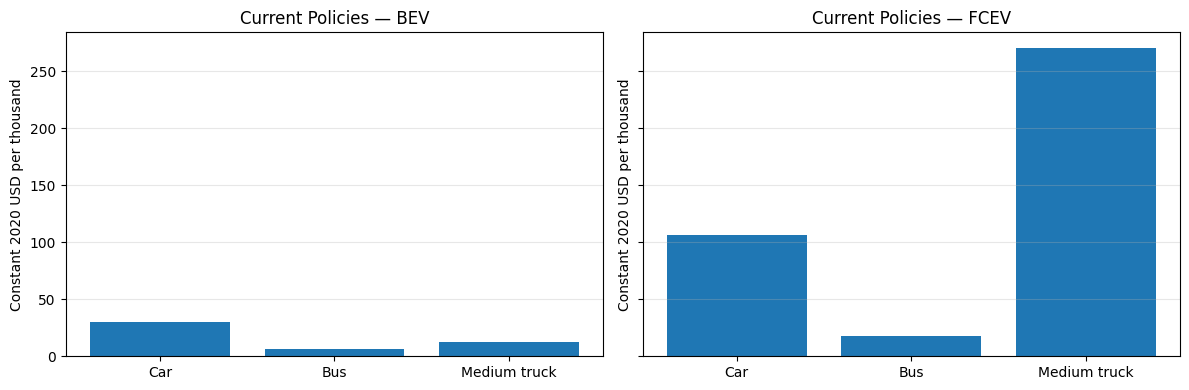

In [21]:
# --- Current Policies plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (lab, d) in zip(axes, [("BEV", cp_bev_veh_plot), ("FCEV", cp_fcev_veh_plot)]):
    ax.bar(d.index, d["subsidy_per_vehicle"])
    ax.set_title(f"Current Policies — {lab}")
    ax.set_ylabel(f"Constant {BASE_PLOT} thousand USD")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(True, axis="y", alpha=0.3)
# plt.suptitle("Subsidy per Vehicle")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (lab, d) in zip(axes, [("BEV", cp_bev_perf_plot), ("FCEV", cp_fcev_perf_plot)]):
    d2 = d.loc[["Car", "Bus", "Medium truck"]]
    ax.bar(d2.index, d2["subsidy_per_perf"])
    ax.set_title(f"Current Policies — {lab}")
    ax.set_ylabel(f"Constant {BASE_PLOT} USD per thousand")
    ax.grid(True, axis="y", alpha=0.3)
# plt.suptitle("Subsidy per Service Output")
plt.tight_layout()
plt.show()

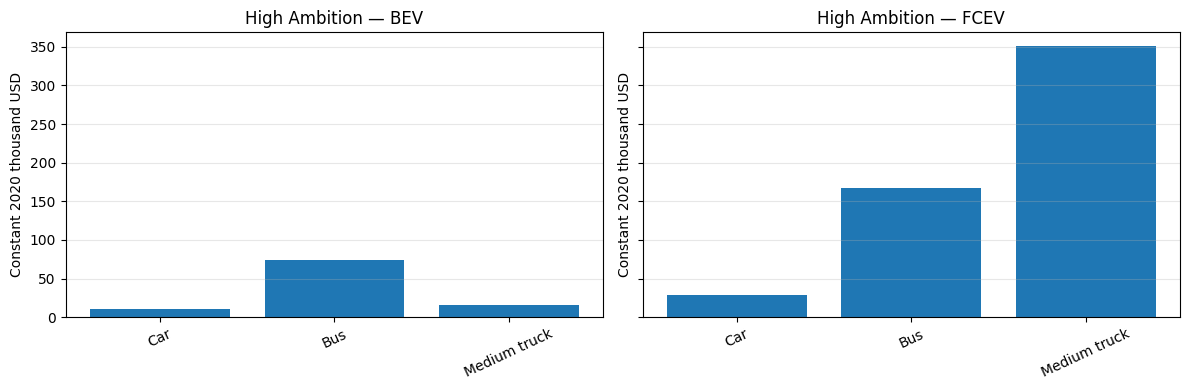

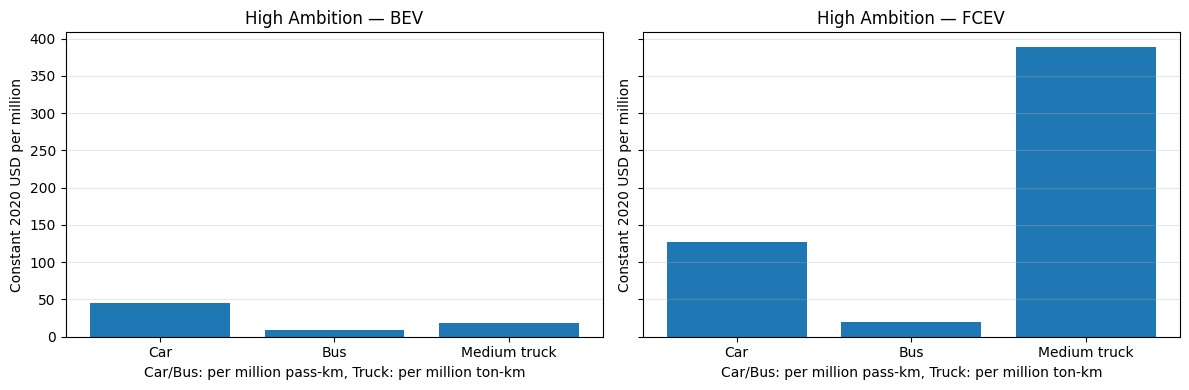

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (lab, d) in zip(axes, [("BEV", ha_bev_veh_plot), ("FCEV", ha_fcev_veh_plot)]):
    ax.bar(d.index, d["subsidy_per_vehicle"])
    ax.set_title(f"High Ambition — {lab}")
    ax.set_ylabel(f"Constant {BASE_PLOT} thousand USD")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (lab, d) in zip(axes, [("BEV", ha_bev_perf_plot), ("FCEV", ha_fcev_perf_plot)]):
    d2 = d.loc[["Car", "Bus", "Medium truck"]]
    ax.bar(d2.index, d2["subsidy_per_perf"])
    ax.set_title(f"High Ambition — {lab}")
    ax.set_ylabel(f"Constant {BASE_PLOT} USD per million")
    ax.set_xlabel("Car/Bus: per million pass-km, Truck: per million ton-km")
    ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
SUBSIDY_NAME = "purchase-subsidy"

# model-base perf subsidies (BASE_INPUT)
bev_car   = float(df_cp_bev_perf.loc["Car", "subsidy_per_perf"])
bev_bus   = float(df_cp_bev_perf.loc["Bus", "subsidy_per_perf"])
bev_truck = float(df_cp_bev_perf.loc["Medium truck", "subsidy_per_perf"])

fcev_car   = float(df_cp_fcev_perf.loc["Car", "subsidy_per_perf"])
fcev_bus   = float(df_cp_fcev_perf.loc["Bus", "subsidy_per_perf"])
fcev_truck = float(df_cp_fcev_perf.loc["Medium truck", "subsidy_per_perf"])

items_cp = [
    dict(supplysector="trn_freight_road", subsector="Medium truck", tech="BEV",
         input_name=SUBSIDY_NAME, input_cost=-bev_truck),
    dict(supplysector="trn_freight_road", subsector="Medium truck", tech="FCEV",
         input_name=SUBSIDY_NAME, input_cost=-fcev_truck),

    dict(supplysector="trn_pass_road_LDV_4W", subsector="Car", tech="BEV",
         input_name=SUBSIDY_NAME, input_cost=-bev_car),
    dict(supplysector="trn_pass_road_LDV_4W", subsector="Car", tech="FCEV",
         input_name=SUBSIDY_NAME, input_cost=-fcev_car),

    dict(supplysector="trn_pass_road_LDV_4W", subsector="Large Car and Truck", tech="BEV",
         input_name=SUBSIDY_NAME, input_cost=-bev_car),
    dict(supplysector="trn_pass_road_LDV_4W", subsector="Large Car and Truck", tech="FCEV",
         input_name=SUBSIDY_NAME, input_cost=-fcev_car),

    dict(supplysector="trn_pass_road", subsector="Bus", tech="BEV",
         input_name=SUBSIDY_NAME, input_cost=-bev_bus),
    dict(supplysector="trn_pass_road", subsector="Bus", tech="FCEV",
         input_name=SUBSIDY_NAME, input_cost=-fcev_bus),
]

# records for years
records_cp = []
for year in [2025]:
    for it in items_cp:
        records_cp.append(dict(**it, year=int(year)))

cp_xml_path = "../../input/policy/korea-2035/transportation/ZEV_purchase_subsidy_cp.xml"
records_to_gcam_xml(records_cp, cp_xml_path)

# High ambition version (use df_ha_* instead)
bev_car   = float(df_ha_bev_perf.loc["Car", "subsidy_per_perf"])
bev_bus   = float(df_ha_bev_perf.loc["Bus", "subsidy_per_perf"])
bev_truck = float(df_ha_bev_perf.loc["Medium truck", "subsidy_per_perf"])

fcev_car   = float(df_ha_fcev_perf.loc["Car", "subsidy_per_perf"])
fcev_bus   = float(df_ha_fcev_perf.loc["Bus", "subsidy_per_perf"])
fcev_truck = float(df_ha_fcev_perf.loc["Medium truck", "subsidy_per_perf"])

items_ha = [
    dict(supplysector="trn_freight_road", subsector="Medium truck", tech="BEV",
         input_name=SUBSIDY_NAME, input_cost=-bev_truck),
    dict(supplysector="trn_freight_road", subsector="Medium truck", tech="FCEV",
         input_name=SUBSIDY_NAME, input_cost=-fcev_truck),

    dict(supplysector="trn_pass_road_LDV_4W", subsector="Car", tech="BEV",
         input_name=SUBSIDY_NAME, input_cost=-bev_car),
    dict(supplysector="trn_pass_road_LDV_4W", subsector="Car", tech="FCEV",
         input_name=SUBSIDY_NAME, input_cost=-fcev_car),

    dict(supplysector="trn_pass_road_LDV_4W", subsector="Large Car and Truck", tech="BEV",
         input_name=SUBSIDY_NAME, input_cost=-bev_car),
    dict(supplysector="trn_pass_road_LDV_4W", subsector="Large Car and Truck", tech="FCEV",
         input_name=SUBSIDY_NAME, input_cost=-fcev_car),

    dict(supplysector="trn_pass_road", subsector="Bus", tech="BEV",
         input_name=SUBSIDY_NAME, input_cost=-bev_bus),
    dict(supplysector="trn_pass_road", subsector="Bus", tech="FCEV",
         input_name=SUBSIDY_NAME, input_cost=-fcev_bus),
]

records_ha = []
for year in range(2025, 2036, 5):
    for it in items_ha:
        records_ha.append(dict(**it, year=int(year)))

ha_xml_path = "../../input/policy/korea-2035/transportation/ZEV_purchase_subsidy_ep.xml"
records_to_gcam_xml(records_ha, ha_xml_path)

print("Wrote XML:")
print(" -", cp_xml_path)
print(" -", ha_xml_path)

Wrote XML:
 - ../../input/policy/korea-2035/transportation/ZEV_purchase_subsidy_cp.xml
 - ../../input/policy/korea-2035/transportation/ZEV_purchase_subsidy_ep.xml
